Text(0.5, 1.0, 'Face')

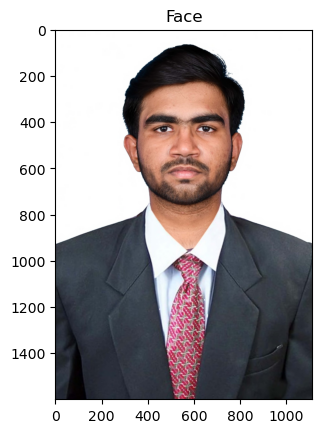

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
faceImage = cv2.imread('pic.jpeg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")

(551, 577, 4)


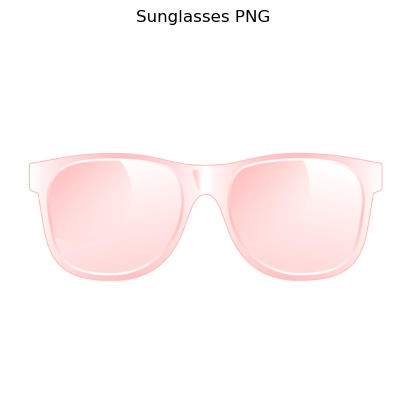

In [10]:
glassPNG = cv2.imread('glass.png', cv2.IMREAD_UNCHANGED)
print(glassPNG.shape)
plt.imshow(glassPNG[:, :, ::-1])
plt.title("Sunglasses PNG")
plt.axis("off")
plt.show()
glassBGR = glassPNG[:, :, 0:3]
glassMask1 = glassPNG[:, :, 3]

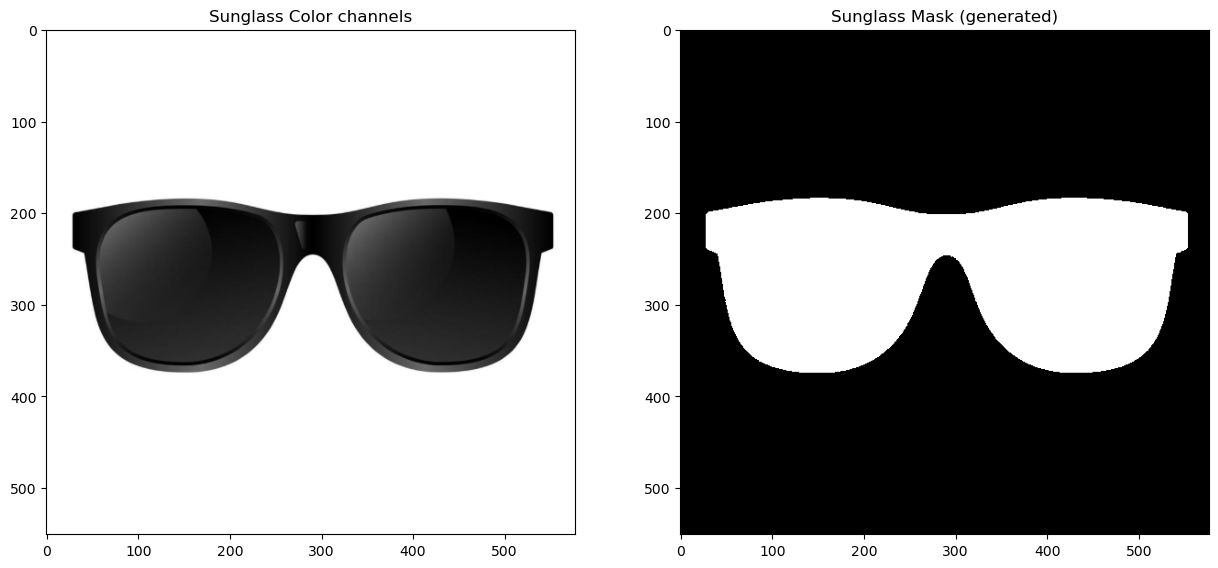

In [7]:
plt.figure(figsize=[15,15])
plt.subplot(121)
plt.imshow(glassPNG[:, :, :3][:, :, ::-1])  # BGR → RGB
plt.title('Sunglass Color channels')
glassBGR = glassPNG[:, :, :3]
glassGray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)
_, glassMask1 = cv2.threshold(glassGray, 240, 255, cv2.THRESH_BINARY_INV)
plt.subplot(122)
plt.imshow(glassMask1, cmap='gray')
plt.title('Sunglass Mask (generated)')
plt.show()

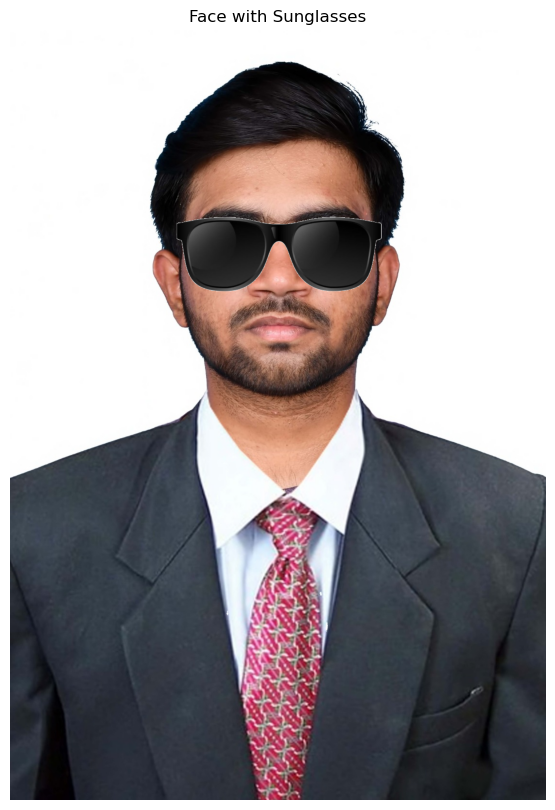

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
faceImage = cv2.imread("pic.jpeg")
glassPNG = cv2.imread("glass.png", cv2.IMREAD_UNCHANGED)
new_w = int(faceImage.shape[1] * 0.42)
new_h = int(new_w * glassPNG.shape[0] / glassPNG.shape[1])
glass_resized = cv2.resize(glassPNG, (new_w, new_h))
if glass_resized.shape[2] == 4:
    glassBGR = glass_resized[:, :, 0:3]
else:
    glassBGR = glass_resized
glassGray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)
_, glassMask = cv2.threshold(glassGray, 240, 255, cv2.THRESH_BINARY_INV)
mask_inv = cv2.bitwise_not(glassMask)
x = int((faceImage.shape[1] - new_w) / 2)
y = int(faceImage.shape[0] * 0.15)
x = max(0, min(x, faceImage.shape[1] - new_w))
y = max(0, min(y, faceImage.shape[0] - new_h))
roi = faceImage[y:y+new_h, x:x+new_w]
bg = cv2.bitwise_and(roi, roi, mask=mask_inv)
fg = cv2.bitwise_and(glassBGR, glassBGR, mask=glassMask)
combined = cv2.add(bg, fg)
faceImage[y:y+new_h, x:x+new_w] = combined
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.title("Face with Sunglasses")
plt.axis("off")
plt.show()